# Another Prototype based on HF Sam 
https://huggingface.co/facebook/sam3

# Step 1
Apply SAM3 to out video frames. Not suitable for interactive feedback

In [1]:
from transformers import Sam3VideoModel, Sam3VideoProcessor
from accelerate import Accelerator
from PIL import Image
import torch
import glob
import os
import numpy as np

In [2]:
device = Accelerator().device
model = Sam3VideoModel.from_pretrained("facebook/sam3").to(device, dtype=torch.bfloat16)
processor = Sam3VideoProcessor.from_pretrained("facebook/sam3")

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

In [3]:
video_path = "./videos/frames"
video_frames_paths = glob.glob(os.path.join(video_path, "*.jpg"))
video_frames_paths.sort(key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
video_frames = [np.array(Image.open(f)) for f in video_frames_paths]

In [4]:
inference_session = processor.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.bfloat16,
)

In [5]:
# Add text prompt to detect and track objects
text = "fish"
inference_session = processor.add_text_prompt(
    inference_session=inference_session,
    text=text,
)

In [6]:
# Process all frames in the video
outputs_per_frame = {}
for model_outputs in model.propagate_in_video_iterator(
    inference_session=inference_session, max_frame_num_to_track=50
):
    processed_outputs = processor.postprocess_outputs(inference_session, model_outputs)
    outputs_per_frame[model_outputs.frame_idx] = processed_outputs

print(f"Processed {len(outputs_per_frame)} frames")

# Access results for a specific frame
frame_0_outputs = outputs_per_frame[0]
print(f"Detected {len(frame_0_outputs['object_ids'])} objects")
print(f"Object IDs: {frame_0_outputs['object_ids'].tolist()}")
print(f"Scores: {frame_0_outputs['scores'].tolist()}")
print(f"Boxes shape (XYXY format, absolute coordinates): {frame_0_outputs['boxes'].shape}")
print(f"Masks shape: {frame_0_outputs['masks'].shape}")


[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Processed 30 frames
Detected 20 objects
Object IDs: [0, 1, 2, 3, 4, 5, 6, 8, 9, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Scores: [0.640625, 0.60546875, 0.54296875, 0.79296875, 0.91015625, 0.546875, 0.5390625, 0.78515625, 0.6640625, 0.55078125, 0.78515625, 0.7421875, 0.7734375, 0.87890625, 0.8828125, 0.89453125, 0.90625, 0.62109375, 0.5703125, 0.875]
Boxes shape (XYXY format, absolute coordinates): torch.Size([20, 4])
Masks shape: torch.Size([20, 480, 853])


In [26]:
outputs_per_frame[0].keys()

dict_keys(['object_ids', 'scores', 'boxes', 'masks', 'prompt_to_obj_ids'])

# Step 2 (outdated)
Save Images 

# Step 3 
Visualize Masks

In [10]:
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

Next steps, the dict with the outputs has to be converted, since `visualization_utils` uses other keys

In [11]:
outputs_new_format2 = []

for frame in range(0, len(outputs_per_frame)):
    frame_data = {}
    frame_data['out_obj_ids'] = outputs_per_frame[frame]['object_ids'].cpu()
    frame_data['out_boxes_xywh'] = outputs_per_frame[frame]['boxes'].cpu()
    frame_data['out_binary_masks'] = outputs_per_frame[frame]['masks'].cpu()
    
    outputs_new_format2.append(frame_data)

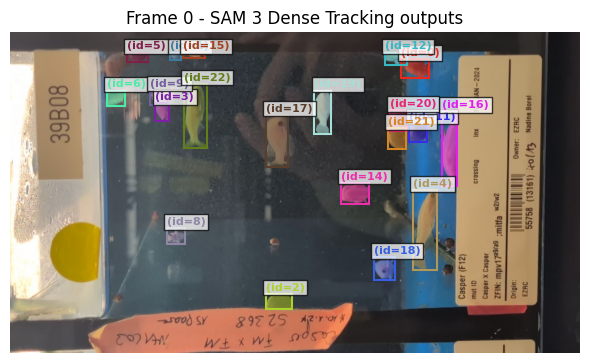

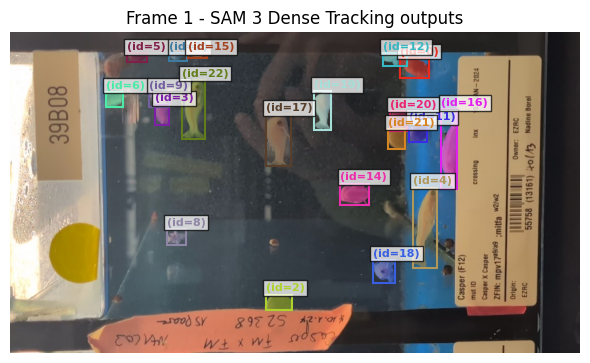

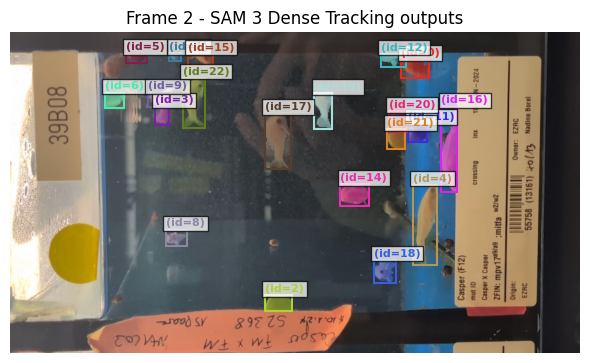

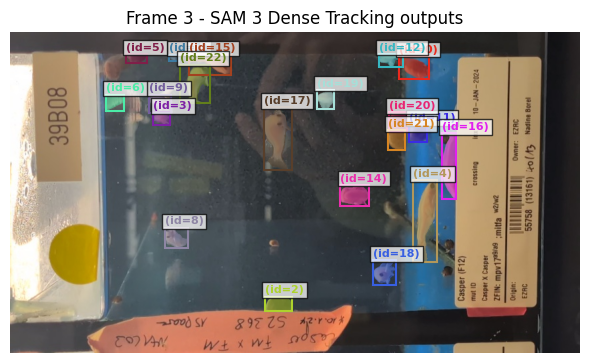

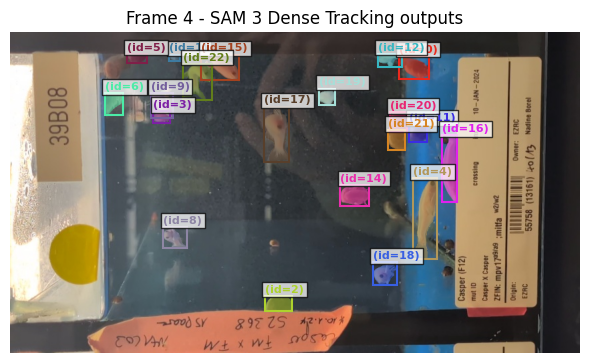

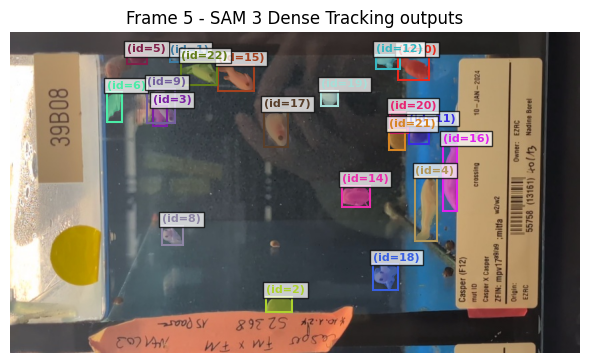

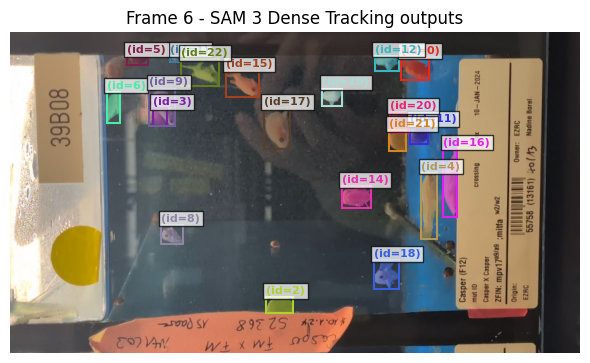

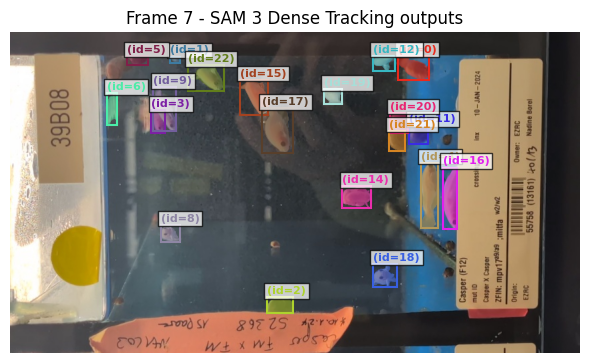

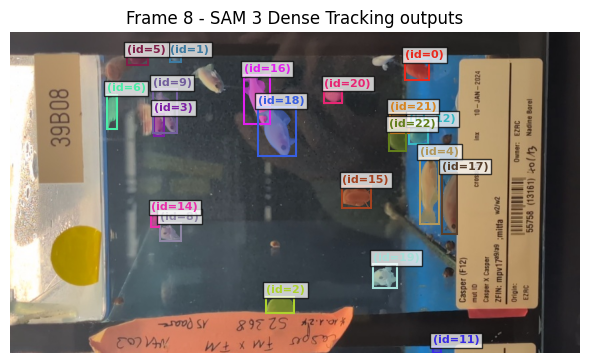

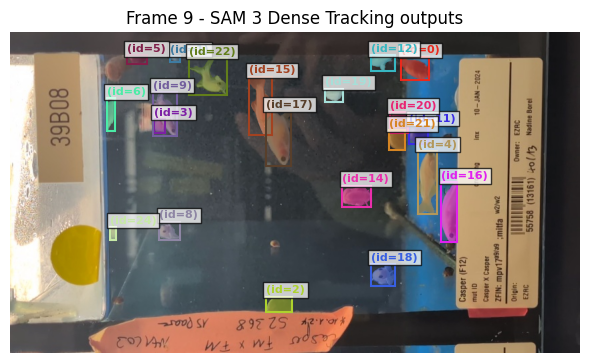

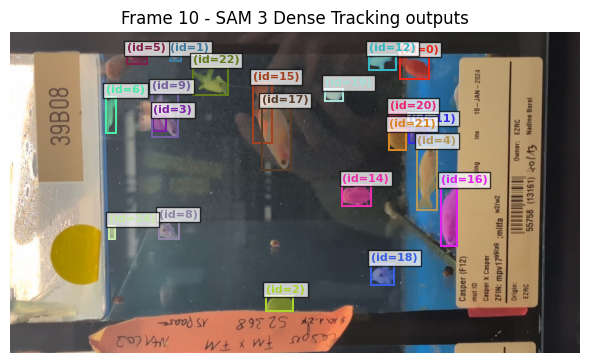

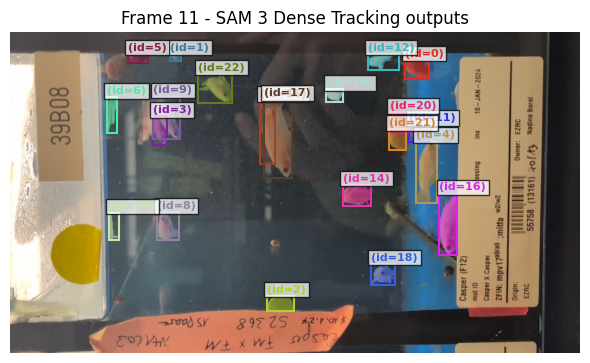

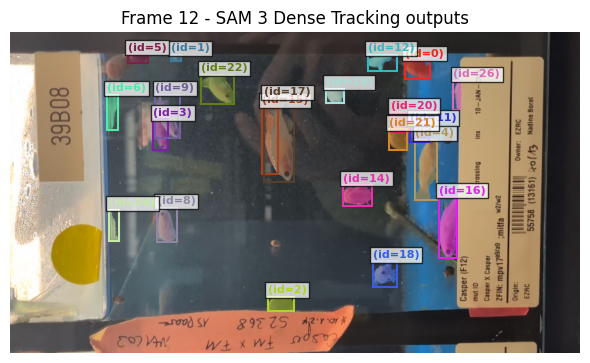

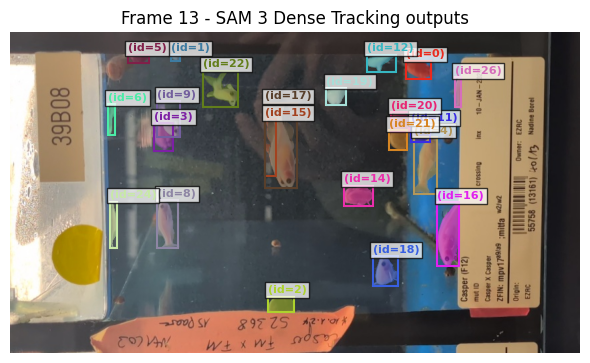

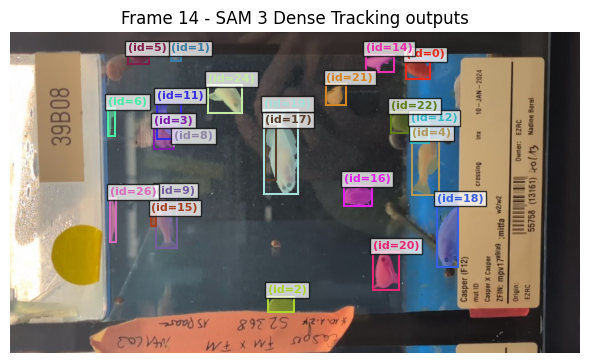

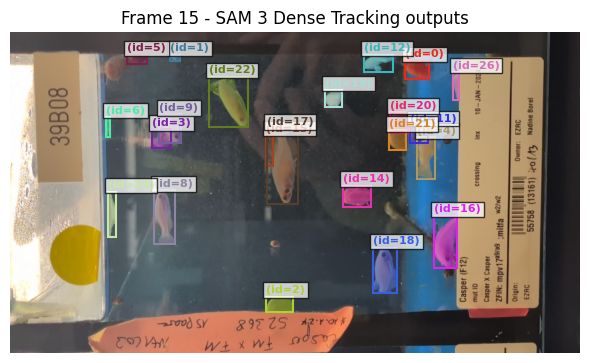

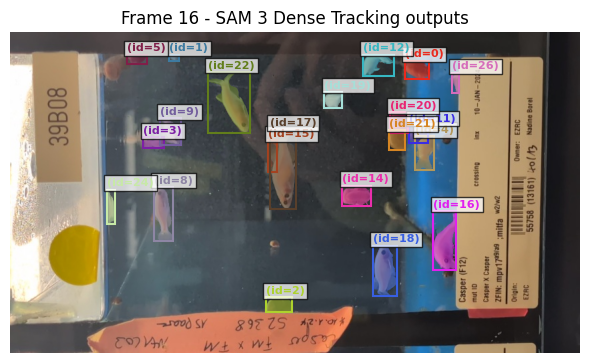

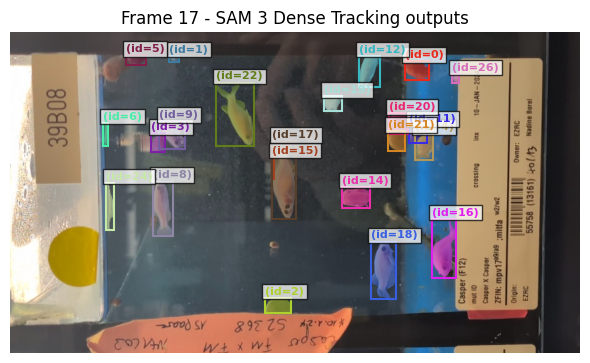

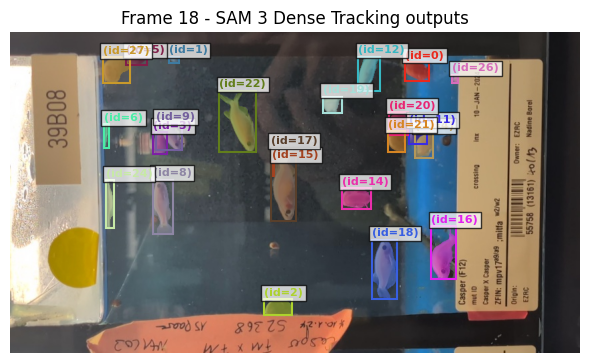

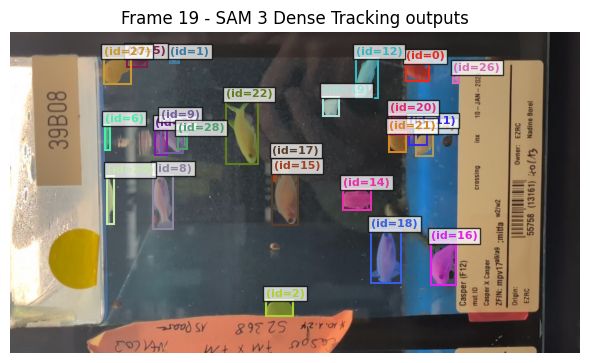

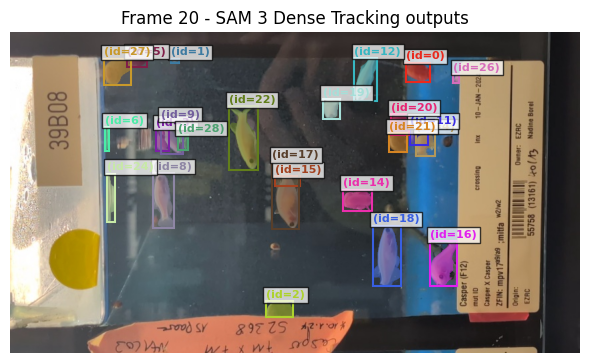

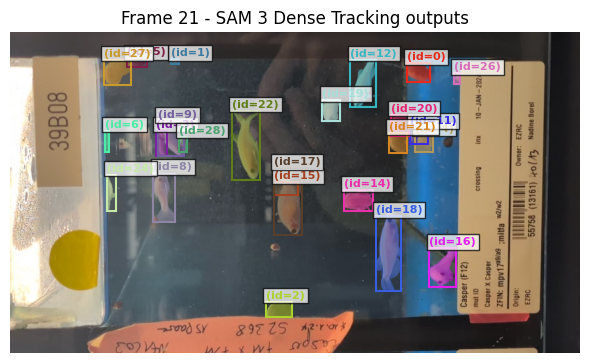

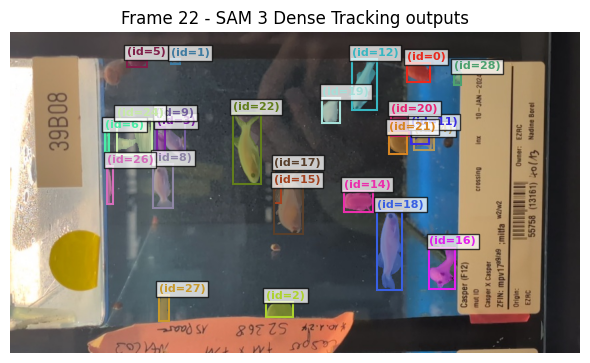

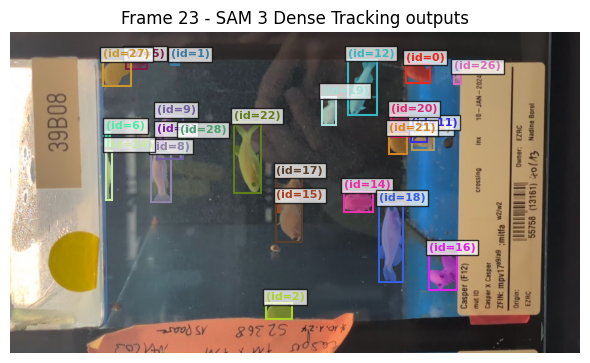

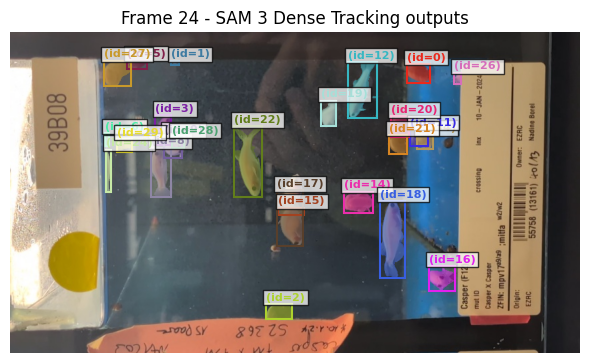

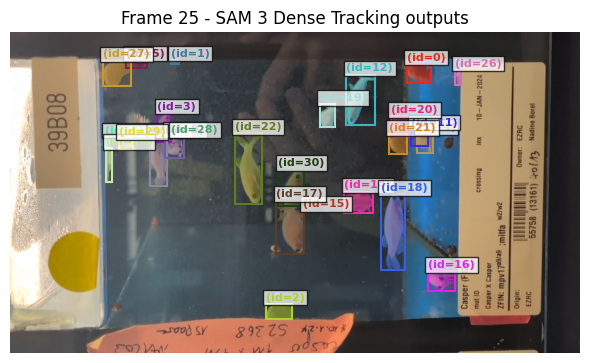

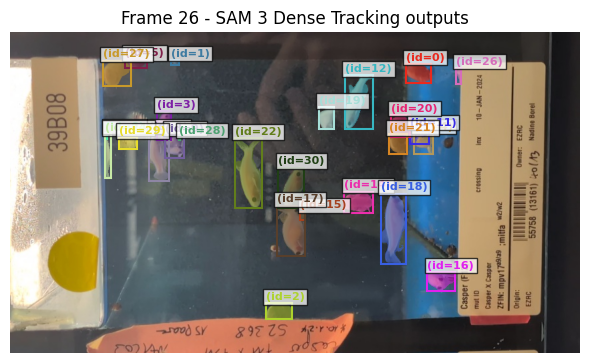

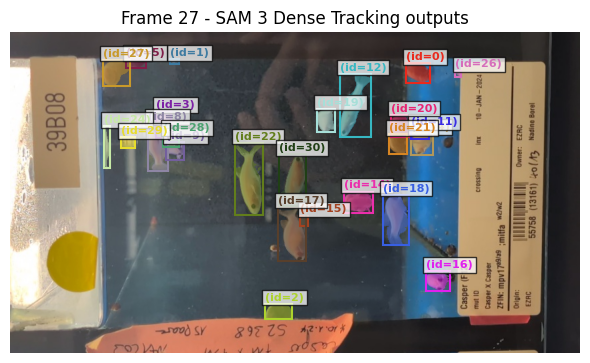

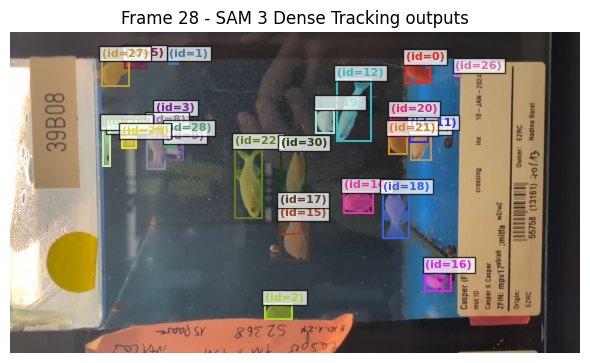

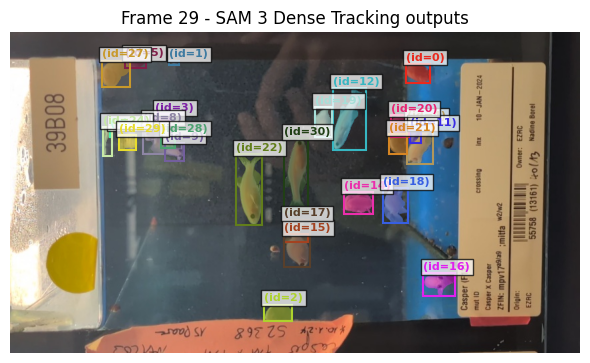

In [12]:
for frame_idx in range(0, len(outputs_new_format2)):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames,
        outputs_list=[prepare_masks_for_visualization({frame_idx: outputs_new_format2[frame_idx]})],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

In [15]:
import os
import matplotlib
# Wechselt den Backend, um sicherzustellen, dass savefig nicht auf ein leeres Bild zugreift
matplotlib.use('Agg') 
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# 1. Zielordner
output_dir = "./outputs"
os.makedirs(output_dir, exist_ok=True)

print(f"Starte Speichern der Frames in {output_dir}...")

for frame_idx in range(len(outputs_new_format2)):
    # Alte Plots explizit löschen
    plt.close('all')
    
    # 2. Visualisierung aufrufen
    # Die Funktion erstellt intern eine Figure und Axes
    visualize_formatted_frame_output(
        frame_idx,
        video_frames,
        outputs_list=[prepare_masks_for_visualization({frame_idx: outputs_new_format2[frame_idx]})],
        titles=["SAM 3 Dense Tracking"],
        figsize=(10, 7),
    )
    
    # 3. Die aktuell erzeugte Figure greifen
    fig = plt.gcf()
    
    # Sicherstellen, dass das Bild gezeichnet wurde
    fig.canvas.draw()
    
    # 4. Das Bild direkt aus dem Speicher in ein PIL-Image umwandeln
    # Das ist sicherer als der Umweg über savefig
    rgba_buffer = fig.canvas.buffer_rgba()
    img = Image.frombuffer('RGBA', fig.canvas.get_width_height(), rgba_buffer, 'raw', 'RGBA', 0, 1)
    img = img.convert("RGB") # Von Alpha zu Standard RGB
    
    # 5. Drehen (Wähle ROTATE_90 oder ROTATE_270)
    # 90 = gegen Uhrzeigersinn, 270 = im Uhrzeigersinn
    img_rotated = img.transpose(Image.ROTATE_270)
    
    # 6. Speichern
    file_name = f"output{frame_idx + 1:04d}.jpg"
    save_path = os.path.join(output_dir, file_name)
    img_rotated.save(save_path, quality=95)
    
    if (frame_idx + 1) % 5 == 0:
        print(f"Frame {frame_idx + 1} erfolgreich gespeichert.")

# WICHTIG: Den interaktiven Modus wieder einschalten, falls du danach noch Plots sehen willst
matplotlib.use('module://matplotlib_inline.backend_inline')
print(f"Fertig! Alle Bilder liegen unter: {os.path.abspath(output_dir)}")

Starte Speichern der Frames in ./outputs...
Frame 5 erfolgreich gespeichert.
Frame 10 erfolgreich gespeichert.
Frame 15 erfolgreich gespeichert.
Frame 20 erfolgreich gespeichert.
Frame 25 erfolgreich gespeichert.
Frame 30 erfolgreich gespeichert.
Fertig! Alle Bilder liegen unter: /mnt/c/Users/sinke/Desktop/Masterarbeit/sam3/outputs


In [21]:
print([method for method in dir(processor) if method.startswith("add")])

['add_text_prompt']
